In [12]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_curve,
    roc_auc_score
)

print(f"All imports done")

All imports done


In [13]:
# Step 2: Create the Customer Churn Dataset

np.random.seed(42)
n = 1000    # 1000 customers

# ── Generate Features ──────────────────────────────
credit_score  = np.random.randint(300, 851, n)    # 300 to 850
age           = np.random.randint(18, 71, n)      # 18 to 70
tenure        = np.random.randint(0, 11, n)       # 0 to 10 years
balance       = np.random.uniform(0, 100000, n)   # $0 to $100,000
num_products  = np.random.randint(1, 5, n)        # 1 to 4 products
is_active     = np.random.randint(0, 2, n)        # 0 or 1

# ── Calculate Churn Probability (the logic) ────────
churn_score = (
    - 0.003 * credit_score     # low score → more likely to churn
    + 0.02  * age              # older     → more likely to churn
    - 0.05  * tenure           # longer    → less likely to churn
    - 0.000005 * balance       # more $    → less likely to churn
    - 0.3   * num_products     # more      → less likely to churn
    - 0.5   * is_active        # active    → less likely to churn
    + 1.5                      # base level (intercept)
)

# Convert score to probability using sigmoid function
churn_prob = 1 / (1 + np.exp(-churn_score))

# Convert probability to actual 0 or 1 (with some randomness)
churn = (churn_prob + np.random.uniform(-0.15, 0.15, n) > 0.5).astype(int)

# ── Build the DataFrame ────────────────────────────
df = pd.DataFrame({
    'credit_score' : credit_score,
    'age'          : age,
    'tenure'       : tenure,
    'balance'      : balance,
    'num_products' : num_products,
    'is_active'    : is_active,
    'churn'        : churn
})

print("Dataset shape:", df.shape)
print()
print("First 5 rows:")
df.head()


Dataset shape: (1000, 7)

First 5 rows:


,credit_score,age,tenure,balance,num_products,is_active,churn
0,402,55,6,16482.467535,1,1,0
1,735,29,7,17058.191156,1,1,0
2,570,40,0,94810.832017,2,0,0
3,406,70,9,44524.611228,1,0,1
4,371,59,9,78880.226391,3,1,0


In [14]:
# Check 1: Shape and types
print("Shape:", df.shape)           
print()
print(df.dtypes)
print()

# Check 2: No missing values
print("Missing values:")
print(df.isnull().sum())           
print()

# Check 3: Class balance — VERY IMPORTANT in classification
print("Churn value counts:")
print(df['churn'].value_counts())
print()
print("Churn percentage:")
print(df['churn'].value_counts(normalize=True).round(3) * 100)


Shape: (1000, 7)

credit_score      int32
age               int32
tenure            int32
balance         float64
num_products      int32
is_active         int32
churn             int64
dtype: object

Missing values:
credit_score    0
age             0
tenure          0
balance         0
num_products    0
is_active       0
churn           0
dtype: int64

Churn value counts:
churn
0    835
1    165
Name: count, dtype: int64

Churn percentage:
churn
0    83.5
1    16.5
Name: proportion, dtype: float64


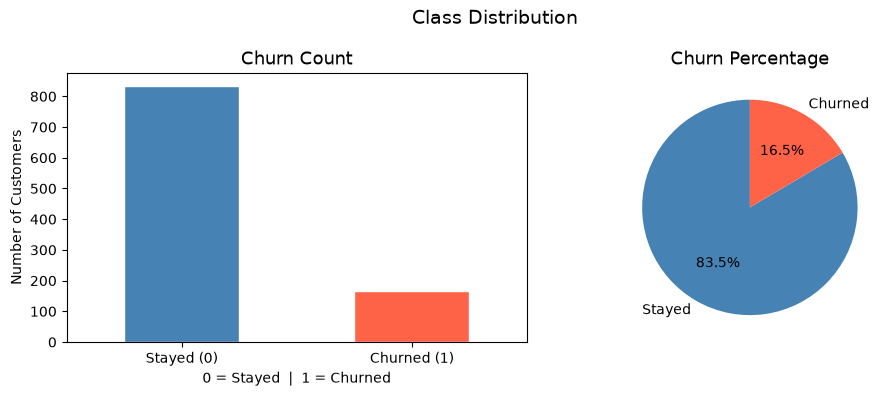

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))


df['churn'].value_counts().plot(kind='bar', ax=axes[0],
    color=['steelblue', 'tomato'], edgecolor='white', width=0.5)
axes[0].set_title("Churn Count", fontsize=13)
axes[0].set_xlabel("0 = Stayed  |  1 = Churned")
axes[0].set_ylabel("Number of Customers")
axes[0].set_xticklabels(['Stayed (0)', 'Churned (1)'], rotation=0)



# Percentage pie chart
labels = ['Stayed', 'Churned']
sizes  = df['churn'].value_counts().values
colors = ['steelblue', 'tomato']
axes[1].pie(sizes, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90)
axes[1].set_title("Churn Percentage", fontsize=13)

plt.suptitle("Class Distribution", fontsize=14)
plt.tight_layout()
plt.show()

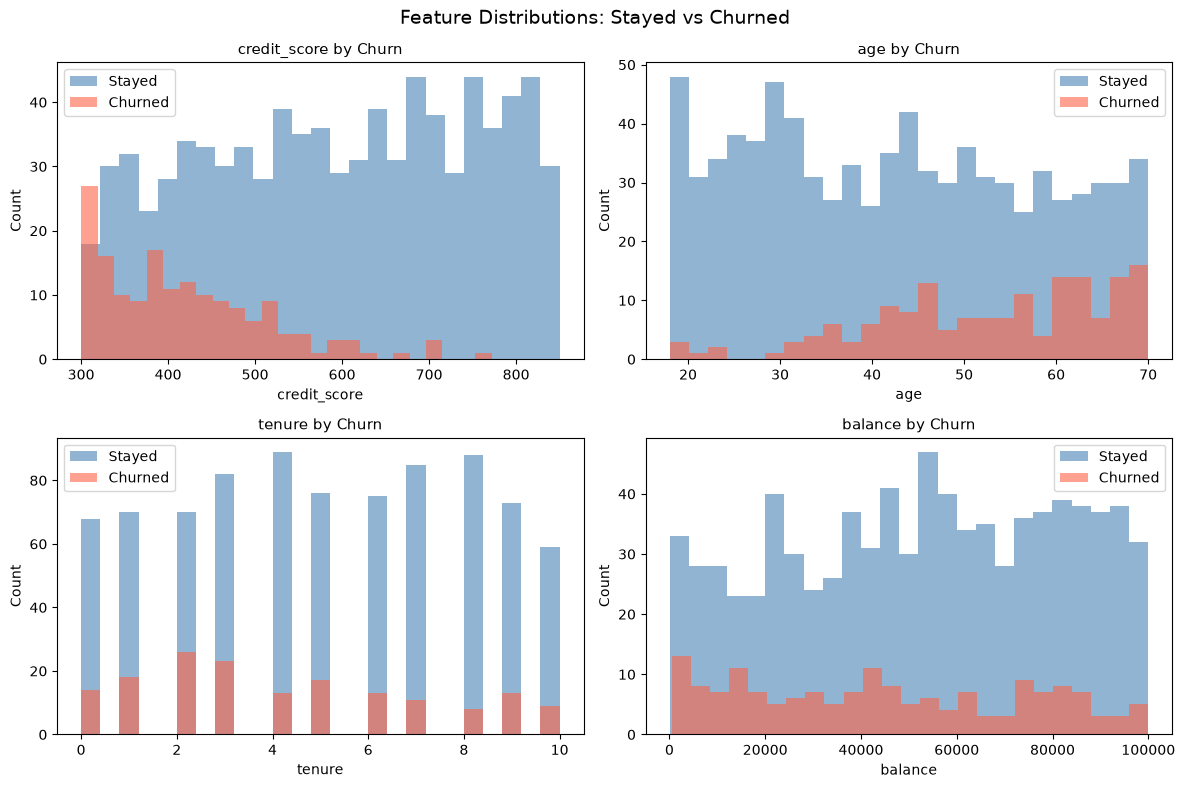

In [16]:

numeric_features = ['credit_score', 'age', 'tenure', 'balance']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    stayed  = df[df['churn'] == 0][feature]
    churned = df[df['churn'] == 1][feature]

    axes[i].hist(stayed,  bins=25, alpha=0.6, color='steelblue', label='Stayed')
    axes[i].hist(churned, bins=25, alpha=0.6, color='tomato',    label='Churned')
    axes[i].set_title(f'{feature} by Churn', fontsize=11)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle("Feature Distributions: Stayed vs Churned", fontsize=14)
plt.tight_layout()
plt.show()


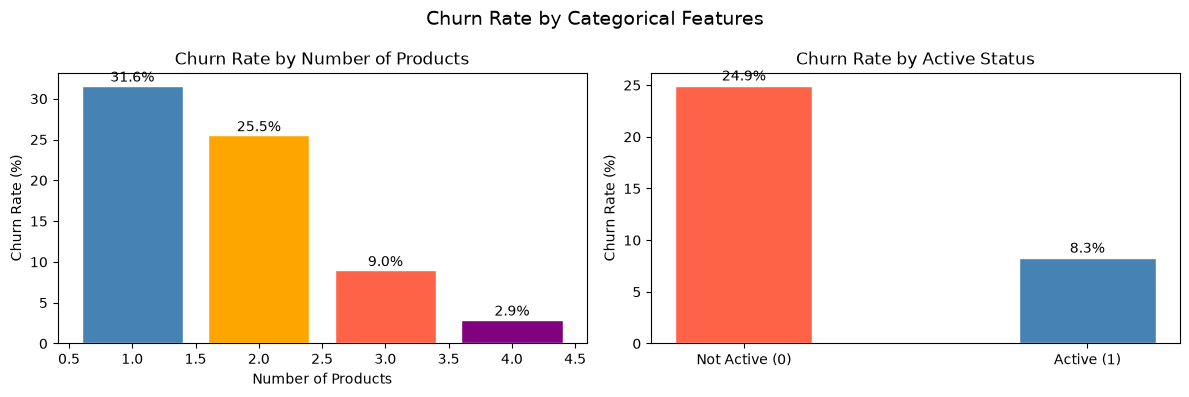

In [18]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_by_products = df.groupby('num_products')['churn'].mean() * 100
axes[0].bar(churn_by_products.index, churn_by_products.values,
            color=['steelblue', 'orange', 'tomato', 'purple'],
            edgecolor='white')
axes[0].set_title("Churn Rate by Number of Products", fontsize=12)
axes[0].set_xlabel("Number of Products")
axes[0].set_ylabel("Churn Rate (%)")
for i, v in enumerate(churn_by_products.values):
    axes[0].text(i + 1, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

churn_by_active = df.groupby('is_active')['churn'].mean() * 100
axes[1].bar(['Not Active (0)', 'Active (1)'], churn_by_active.values,
            color=['tomato', 'steelblue'], edgecolor='white', width=0.4)
axes[1].set_title("Churn Rate by Active Status", fontsize=12)
axes[1].set_ylabel("Churn Rate (%)")
for i, v in enumerate(churn_by_active.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=10)

plt.suptitle("Churn Rate by Categorical Features", fontsize=14)
plt.tight_layout()
plt.show()


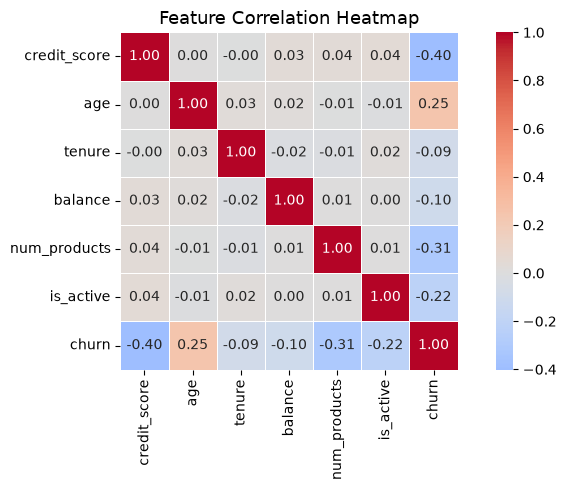

In [19]:

plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title("Feature Correlation Heatmap", fontsize=13)
plt.tight_layout()
plt.show()


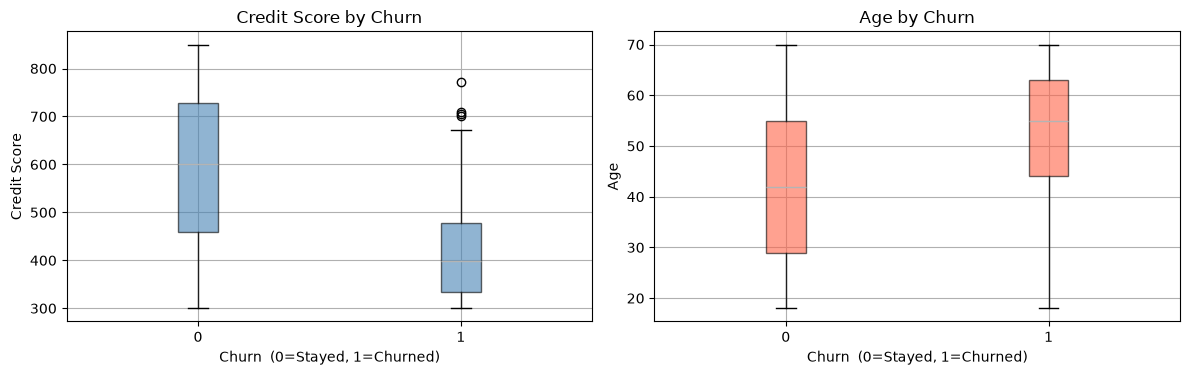

In [20]:
# Step 3E: Boxplots — feature spread by churn class

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Credit score by churn
df.boxplot(column='credit_score', by='churn', ax=axes[0],
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[0].set_title("Credit Score by Churn")
axes[0].set_xlabel("Churn  (0=Stayed, 1=Churned)")
axes[0].set_ylabel("Credit Score")

# Age by churn
df.boxplot(column='age', by='churn', ax=axes[1],
           patch_artist=True,
           boxprops=dict(facecolor='tomato', alpha=0.6))
axes[1].set_title("Age by Churn")
axes[1].set_xlabel("Churn  (0=Stayed, 1=Churned)")
axes[1].set_ylabel("Age")

plt.suptitle("")
plt.tight_layout()
plt.show()


In [21]:
# Step 3F: Mean of each feature grouped by churn

print("Average feature values by churn class:")
print("=" * 55)
print(df.groupby('churn').mean().round(2).T.to_string())
print("=" * 55)


Average feature values by churn class:
churn                0         1
credit_score    593.59    419.68
age              42.59     52.67
tenure            5.02      4.25
balance       52607.68  44625.30
num_products      2.73      1.79
is_active         0.56      0.25
